# Weighted Stacking Pipeline — Radio Recombination Lines (CI α RRLs)

This notebook stacks individual Carbon Radio Recombination Line (RRL) transitions
from a NenuFAR *alltime* FITS spectrum to boost the signal-to-noise ratio.

## How to use this notebook

**You only need to edit one cell: `⚙️ 1 — Configuration`.** 
Everything below runs automatically once you set your paths and parameters there.

---

## Pipeline overview

| Step | What it does |
|------|--------------|
| 1 | **Configuration** — set your source, paths, and stacking parameters |
| 2 | **Imports** — load libraries (no editing needed) |
| 3 | **Load spectrum** — open the FITS file and build the frequency axis |
| 4 | **Extract lines** — slice a fixed-width window around each transition |
| 5 | **Compute S/N** — measure the signal-to-noise of each isolated line |
| 6 | **Stack** — weighted average within each quantum-number interval |
| 7 | **Save** — write the stacks to disk |
| 8 | **Visualise** — mosaic plot of all stacked spectra |

---

### Dependencies
```
numpy  matplotlib  astropy  scipy  tqdm
spectral_tools  (local — install with: pip install -e .)
```


---
## ⚙️  1 — Configuration

> **Edit this cell only.** All other cells read from these variables.

### Quick-start examples

| Source | `SOURCE` | `MY_LINE` | `USE_OFF` |
|--------|----------|-----------|-----------|
| Tau A clouds | `"TAUA_CLOUDS"` | `"Calph"` | `True` |
| Tau A direct | `"TAU_A"` | `"Calph"` | `False` |
| Cas A | `"CAS_A"` | `"Calph"` | `True` |

### Stacking interval guide

The pipeline uses **three n-ranges** with different bin widths:
- `n < N0_STACK` (low-n, strong lines) → coarser bins (`QI[0]`)
- `N0_STACK ≤ n ≤ N1_STACK` (mid-n, best S/N) → finer bins (`QI[1]`)
- `n > N1_STACK` (high-n, weak lines) → coarser bins (`QI[2]`)

Decrease `QI[1]` for finer sampling in the mid-n range (more panels, lower S/N per panel).


In [1]:
# =============================================================================
#  CONFIGURATION  —  edit here, do not touch anything below
# =============================================================================

# --- Source -------------------------------------------------------------------
SOURCE   = "TAUCLOUDS_HI"   # Short identifier used in filenames (no spaces)
MY_LINE  = "Calph"          # RRL series: 'Calph' for Carbon α transitions
USE_OFF  = False             # True  → use the OFF-subtracted (reference) spectrum
                            # False → use the ON spectrum directly

# --- Paths --------------------------------------------------------------------
# Folder containing the alltime FITS file (relative to this notebook, or absolute)
FITS_DIR   = "../data/alltimes"

# CSV table of RRL frequencies  (ship with spectral_tools)
PATH_LINES = "../files/rrlines.csv"

# Folder where the stacks text file will be written (created if absent)
OUTPUT_DIR = "../data/stacks"

# --- Spectral extraction window -----------------------------------------------
WIDTH    = 1000   # Total window width in channels (centred on each line)
                  # Increase for wider velocity coverage; decrease to speed up.

VELO_SYS = 0      # Systemic velocity offset to apply when fetching line frequencies [Hz]
                  # Set to the LSR velocity of your source if needed.

# --- Noise / weight calibration -----------------------------------------------
OG          = 1e4  # Optical-depth gain: raw data ÷ OG → optical depth units
CAP_CALIB   = True # Prevent very bright lines from dominating the stack weights
VAL_MAX_SNR = 6    # If CAP_CALIB=True, any line with S/N > VAL_MAX_SNR is
                   # down-weighted so its effective S/N equals VAL_MAX_SNR

# --- Contaminated-line rejection (S/N thresholds) ----------------------------
# A line is EXCLUDED from the stack if its S/N falls OUTSIDE the window
# [SNR_MIN, SNR_MAX], i.e.:
#   S/N < SNR_MIN → likely emission-contaminated   (excluded)
#   S/N > SNR_MAX → too noisy / undetected          (excluded)
#
# Typical values: SNR_MIN=0.0, SNR_MAX=0.8
# Lower SNR_MAX → stricter; fewer lines used but less contamination risk.
SNR_MIN = 0.0
SNR_MAX = VAL_MAX_SNR

# --- Stacking intervals in quantum number n -----------------------------------
# Three-zone binning: [step_low_n, step_mid_n, step_high_n]
QI       = [40, 20, 50]
N0_STACK = 500   # n boundary between low and mid zones
N1_STACK = 730   # n boundary between mid and high zones

# --- Visualisation ------------------------------------------------------------
REBIN_FACTOR = 4   # Number of channels averaged per output bin in the mosaic plot
                   # Higher → smoother but lower frequency resolution
MOSAIC_COLS  = 4   # Number of columns in the mosaic grid

# =============================================================================
#  Derived paths — auto-built from the settings above, do not edit
# =============================================================================
import os
_off_str   = '_OFF' if USE_OFF else ''
_basename  = f"{SOURCE}_{MY_LINE}{_off_str}"

PATH_FITS   = os.path.join(FITS_DIR,   f"alltime_{_basename}.fits")
PATH_STACKS = os.path.join(OUTPUT_DIR, f"STACKS-{SOURCE}{_off_str}.txt")
PATH_PDF    = f"../figures/Stacking/{SOURCE}{_off_str}-detections.pdf"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded")
print(f"  FITS file  : {PATH_FITS}")
print(f"  Line table : {PATH_LINES}")
print(f"  Output     : {PATH_STACKS}")
print(f"  PDF figure : {PATH_PDF}")


Configuration loaded
  FITS file  : ../data/alltimes/alltime_TAUCLOUDS_HI_Calph.fits
  Line table : ../files/rrlines.csv
  Output     : ../data/stacks/STACKS-TAUCLOUDS_HI.txt
  PDF figure : ../figures/Stacking/TAUCLOUDS_HI-detections.pdf


---
## 2 — Imports & plot style

*No editing needed.*


In [2]:
%matplotlib widget

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
from tqdm import tqdm

# Local spectral-analysis package — install with: pip install -e .
import spectral_tools.tools as tools
import spectral_tools.graphics as graphics
import spectral_tools.io as io
import spectral_tools.stacking as stacking
# ── Plot style ────────────────────────────────────────────────

graphics.set_style()


---
## 3 — Load the FITS spectrum

Reads the *alltime* FITS file and reconstructs the frequency axis from the
WCS header keywords (`CRVAL3`, `CDELT3`, `CRPIX3`, `NAXIS3`).
The line-frequency table is then filtered to the observed bandwidth.


In [3]:
# ── Open FITS file ────────────────────────────────────────────────────────
if not os.path.isfile(PATH_FITS):
    raise FileNotFoundError(
        f"FITS file not found: {PATH_FITS}\n"
        "Check FITS_DIR and SOURCE/MY_LINE/USE_OFF in the Configuration cell."
    )

full_spectrum = fits.open(PATH_FITS)

# ── Reconstruct the linear frequency axis ──────────────
hdr   = full_spectrum[0].header
# CRVAL = hdr['CRVAL3']
# CDELT = hdr['CDELT3']   # Spectral resolution [Hz/channel]
# CRPIX = hdr['CRPIX3']
NAXIS = hdr['NAXIS3']
df    = hdr['CDELT3']

I   = full_spectrum[0].data[:, 0, 0]   # Intensity spectrum
RMS = full_spectrum[2].data[:, 0, 0]   # Per-channel RMS noise
# f   = np.array([CRVAL + (i - CRPIX) * CDELT for i in range(NAXIS)])  # Frequency axis [GHz]
f = io.freq_axis_from_fits(full_spectrum)

# ── Retrieve line frequencies within the observed band ───────────────────
fmini  = hdr["FMIN"]
fmaxi  = hdr["FMAX"]   # Upper boundary of NenuFAR lane 0 [GHz]
Lines  = tools.get_line(fmini, fmaxi, VELO_SYS, line=MY_LINE, path=PATH_LINES)

lowest_n  = int(np.min(Lines.index))
highest_n = int(np.min((np.max(Lines.index), 850)))

print(f"Spectrum loaded  : {NAXIS} channels,  {f[0]:.3f} – {f[-1]:.3f} GHz")
print(f"RMS (median)     : {np.nanmedian(RMS):.4g}")
print(f"Lines in band    : n = {lowest_n} … {highest_n}  ({highest_n - lowest_n} transitions)")


Spectrum loaded  : 786556 channels,  10.058 – 85.070 GHz
RMS (median)     : 0.0001933
Lines in band    : n = 426 … 850  (424 transitions)


---
## 4 — Extract individual lines & compute weights

For each quantum number `n`, the pipeline:
1. Slices a window of `WIDTH` channels centred on the expected line frequency.
2. Blanks channels with NaN or unrealistically large amplitudes.
3. **Rejects** lines where more than 40 % of channels are blank.
4. Computes the weight as `1/rms²`; if `CAP_CALIB=True`, the weight is
   capped so that no single bright line dominates the stack.


In [4]:
lines, weights, fref, snrs = stacking.extract_weighted_lines(
         f, I, RMS, Lines, width=1000,
         lowest_n=int(Lines.index.min()),
         highest_n=int(Lines.index.max()),
    )
lines = np.array(lines, dtype=float)

Extracting lines: 100%|█████████████████████| 424/424 [00:00<00:00, 1717.32it/s]


Extraction complete: 363 accepted, 61 rejected (>40% blank), 0 out-of-band.


---
## 5 — Compute S/N per transition & define stacking intervals

**S/N estimation:** signal = mean of the central third of the window;
noise = std of the wings (outer half, with the central half masked).
The sign is flipped because absorption lines have negative intensity.

**Stacking intervals:** quantum numbers are grouped into bins of varying
width (set by `QI` in the Configuration cell).
Finer bins in the mid-n range trade S/N for frequency resolution.


In [5]:
# ── S/N per transition ────────────────────────────────────────────────────
snr_all = []
for line in lines :
    snr, _ = stacking.compute_line_snr(line, width=1000)
    snr_all.append(snr)
    
snr_all = np.array(snr_all, dtype=float)
_valid   = np.isfinite(snr_all)

print(f"S/N range (finite lines): {snr_all[_valid].min():.2f} … {snr_all[_valid].max():.2f}")
print(f"Lines with S/N in [{SNR_MIN}, {SNR_MAX}]: "
      f"{np.sum((snr_all >= SNR_MIN) & (snr_all <= SNR_MAX))}")

S/N range (finite lines): -2.25 … 3.49
Lines with S/N in [0.0, 6]: 250


In [6]:
# ── Stacking intervals ────────────────────────────────────────────────────

quantum_intervals = stacking.build_quantum_intervals(lowest_n, highest_n, QI, N0_STACK, N1_STACK)
nstacks           = len(quantum_intervals) - 1

print(f"\nStacking intervals : {quantum_intervals}")
print(f"Number of stacks   : {nstacks}")


Stacking intervals : [426 466 506 526 546 566 586 606 626 646 666 686 706 726 746 796 846]
Number of stacks   : 16


---
## 6 — Weighted stacking

Within each quantum-number interval, lines are combined with `1/σ²` weights.
A line is **excluded** if its S/N lies outside `[SNR_MIN, SNR_MAX]`
(emission contamination or undetected line — set in the Configuration cell).


In [7]:
stacks, n_used = stacking.weighted_stack(
         lines, weights, snr_all,
         quantum_intervals=quantum_intervals, lowest_n=lowest_n, width=1000,
         snr_min=0.0, snr_max=VAL_MAX_SNR,
     )

Stacking: 100%|███████████████████████████████| 16/16 [00:00<00:00, 1774.38it/s]


Stacking complete.
              Interval  n_used
           n = 426…466      19
           n = 466…506      25
           n = 506…526      16
           n = 526…546      18
           n = 546…566      16
           n = 566…586      13
           n = 586…606      19
           n = 606…626      15
           n = 626…646      14
           n = 646…666      12
           n = 666…686      14
           n = 686…706      15
           n = 706…726      11
           n = 726…746      11
           n = 746…796      24
           n = 796…846       8


---
## 7 — Mosaic visualisation

Each panel shows one stacked spectrum after spectral rebinning
(`REBIN_FACTOR` channels → 1 output bin).
The label inside each panel gives the mid-interval quantum number
and the corresponding representative line frequency in GHz.

> **Tip:** increase `REBIN_FACTOR` in the Configuration cell to smooth
> the profiles; decrease it to inspect fine spectral structure.


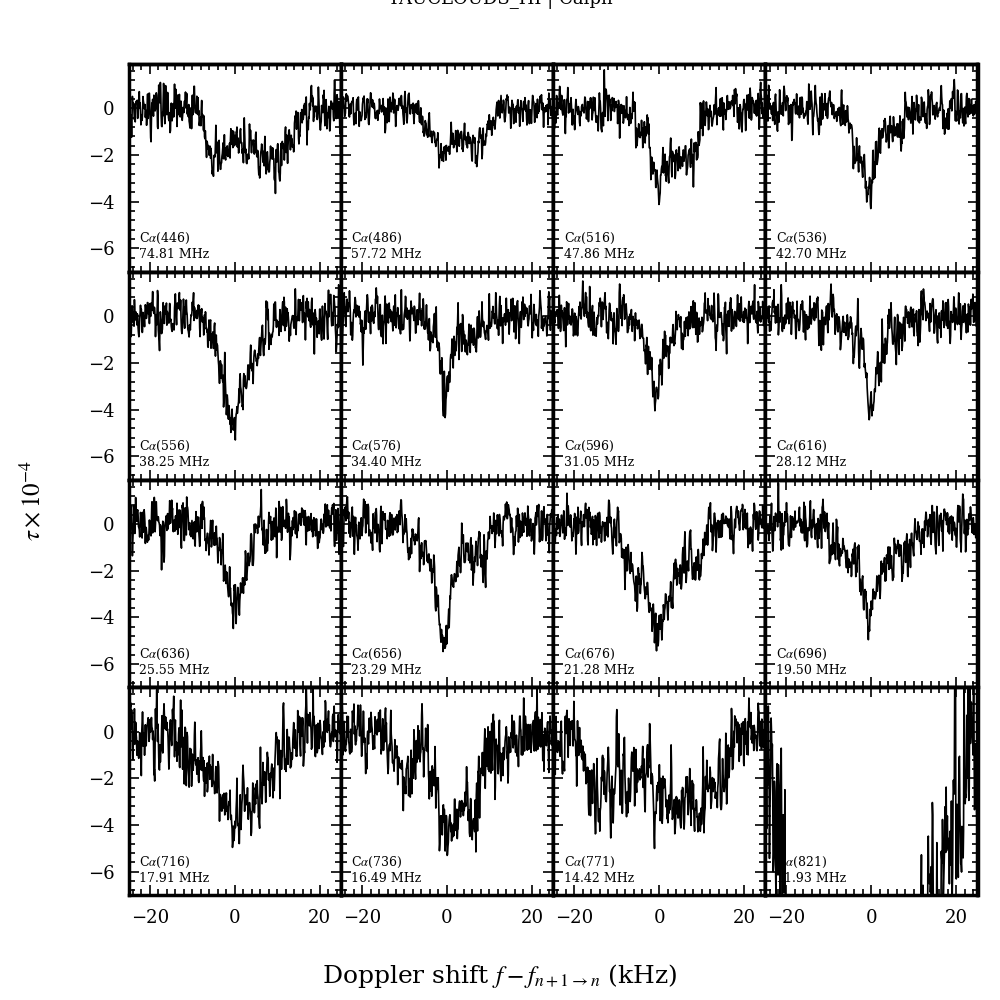

In [8]:

fig, axes = graphics.plot_stack_mosaic(
         stacks, quantum_intervals, fref,
         line_freq_fn=tools.line_freq,
         rebin_fn=tools.rebinning,
         set_axes_fn=graphics.set_axes,
         rebin_factor=1,
         xlim = (-25,25),
         tau_scale = OG,
         title=f"{SOURCE}{_off_str} | {MY_LINE}",
     )

In [9]:
fig.savefig(PATH_PDF, bbox_inches='tight')
print(f"Figure saved → {PATH_PDF}")


Figure saved → ../figures/Stacking/TAUCLOUDS_HI-detections.pdf


---
## 7 — Save stacks to disk

The output text file has one row per stack:
`n_min  n_max  channel_0  channel_1  …  channel_{WIDTH-1}`


In [10]:
qbounds = np.column_stack([quantum_intervals[:-1], quantum_intervals[1:]])
np.savetxt(PATH_STACKS, np.concatenate((qbounds, stacks), axis=1))
print(f"Stacks saved → {PATH_STACKS}")
print(f"  Shape: {stacks.shape}  ({nstacks} stacks × {WIDTH} channels)")


Stacks saved → ../data/stacks/STACKS-TAUCLOUDS_HI.txt
  Shape: (16, 1000)  (16 stacks × 1000 channels)


In [12]:
df*1e6

95.367431640625